In [1]:
import matplotlib.pyplot as plt
#import mplhep as hep
import json

In [2]:
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())
markers = ['o','s','v','^']

In [3]:
with open('dataset2s/residuals.json') as f:
    residuals = json.load(f)

#keys = ['1-noquant_20t','2-noquant_2t','3-input_dig_2t','4-quantized']
#residuals = {key:{k:residuals_flipped[k][key] for k in residuals_flipped if key in residuals_flipped[k]} for key in keys}

In [4]:
fontsize=16
plt.rc('font', size=fontsize-4)

In [5]:
#vbl_names = {'x':r'Predicted - true $x$ [um]', 'y':r'Predicted - true $y$ [um]', 'A':r'Predicted - true $\alpha$ [deg]', 'B':r'Predicted - true $\beta$ [deg]'}

vbl_names = {'x':r'$R_x$ [um]', 'y':r'$R_y$ [um]', 'A':r'$R_\alpha$ [deg]', 'B':r'$R_\beta$ [deg]'}

In [6]:
def draw_one_vbl_slim(vbl, x, d, names, ax_ii):
    
    x_array = [-1*x+0.3 - 0.2*i for i in range(len(names))]
    y_array = [d[k]['mean_'+vbl] for k in names]
    yerr_array = [[d[k]['down68_'+vbl] for k in names],[d[k]['up68_'+vbl] for k in names]]
    
    alpha = [int(num > 0) for num in yerr_array[0]]
    
    line = ax_ii.errorbar(x = y_array, y = x_array, xerr=yerr_array, color = colors[x+4], linestyle='')
    
    dot1 = ax_ii.scatter(y_array[0], x_array[0], marker='o', color = colors[x+4], alpha = alpha[0])
    if len(y_array) > 1:
        dot2 = ax_ii.scatter(y_array[1], x_array[1], marker='s', color = colors[x+4], alpha = alpha[1])
    if len(y_array) > 2:
        dot3 = ax_ii.scatter(y_array[2], x_array[2], marker='v', color = colors[x+4], alpha = alpha[2])
    if len(y_array) > 3:
        dot4 = ax_ii.scatter(y_array[3], x_array[3], marker='^', color = colors[x+4], alpha = alpha[3])

    dot1 = ax_ii.scatter([0], [-99], marker='o', color = 'black')
    dot2 = ax_ii.scatter([0], [-99], marker='s', color = 'black')
    dot3 = ax_ii.scatter([0], [-99], marker='v', color = 'black')
    dot4 = ax_ii.scatter([0], [-99], marker='^', color = 'black')
    ax_ii.set_xlabel(vbl_names[vbl],fontsize=fontsize)
    ax_ii.set_yticks([])

    return [line], [dot1,dot2,dot3,dot4]

def draw_one_vbl(vbl, x, d, names, ax_ii):
    
    x_array = [-1*x+0.3 - 0.2*i for i in range(len(names))]
    print(x_array)
    y_array = [d[k]['mean_'+vbl] for k in names]
    yerr_array = [[d[k]['down68_'+vbl] for k in names],[d[k]['up68_'+vbl] for k in names]]
    yerr2_array = [[d[k]['mean_downsigma'+vbl] for k in names],[d[k]['mean_upsigma'+vbl] for k in names]]
    
    alpha = [int(num > 0) for num in yerr_array[0]]
    
    line1 = ax_ii.errorbar(x = y_array, y = x_array, xerr=yerr_array, color = colors[x], linestyle='')
    line2 = ax_ii.errorbar(x = y_array, y = x_array, xerr=yerr2_array, elinewidth=10, alpha=0.2, color = colors[x], linestyle='')
    
    dot1 = ax_ii.scatter(y_array[0], x_array[0], marker='o', color = colors[x], alpha = alpha[0])
    if len(y_array) > 1:
        dot2 = ax_ii.scatter(y_array[1], x_array[1], marker='s', color = colors[x], alpha = alpha[1])
    if len(y_array) > 2:
        dot3 = ax_ii.scatter(y_array[2], x_array[2], marker='v', color = colors[x], alpha = alpha[2])
    if len(y_array) > 3:
        dot4 = ax_ii.scatter(y_array[3], x_array[3], marker='^', color = colors[x], alpha = alpha[3])

    dot1 = ax_ii.scatter([0], [-99], marker='o', color = 'black')
    dot2 = ax_ii.scatter([0], [-99], marker='s', color = 'black')
    dot3 = ax_ii.scatter([0], [-99], marker='v', color = 'black')
    dot4 = ax_ii.scatter([0], [-99], marker='^', color = 'black')
    ax_ii.set_xlabel(vbl_names[vbl],fontsize=fontsize)
    ax_ii.set_yticks([])

    return [line1,line2], [dot1,dot2,dot3,dot4]
    
def draw_one_model(x, d, names, ax, slim = False):

    if slim:     
        line, dots = draw_one_vbl_slim('x', x, d, names, ax[1][0])
        line, dots = draw_one_vbl_slim('y', x, d, names, ax[1][1])
        line, dots = draw_one_vbl_slim('B', x, d, names, ax[1][2])
        
    else:
        line, dots = draw_one_vbl('x', x, d, names, ax[1][0])
        line, dots = draw_one_vbl('y', x, d, names, ax[1][1])
        line, dots = draw_one_vbl('A', x, d, names, ax[1][2])
        line, dots = draw_one_vbl('B', x, d, names, ax[1][3])

    return line, dots


In [7]:
def format_plot(ax, n_models, slim=False):
    ax[1][0].plot([0,0],[-1-n_models,1],color='gray', zorder=0)
    ax[1][1].plot([0,0],[-1-n_models,1],color='gray', zorder=0)
    ax[1][2].plot([0,0],[-1-n_models,1],color='gray', zorder=0)

    # x limits
    ax[1][0].set_xlim(-15,15) # x
    ax[1][1].set_xlim(-3,3) # y
    ax[1][2].set_xlim(-5,5) # beta
    
    ax[1][0].set_ylim(0.5-n_models,0.5)
    ax[1][1].set_ylim(0.5-n_models,0.5)
    ax[1][2].set_ylim(0.5-n_models,0.5)

    if not slim:
        ax[1][3].plot([0,0],[-1-n_models,1],color='gray', zorder=0)
        ax[1][3].set_ylim(0.5-n_models,0.5)  
        ax[1][2].set_xlim(-5,5) # alpha
        ax[1][3].set_xlim(-5,5) # reset beta

Model = max_2dconv--------------
[0.3, 0.09999999999999998, -0.10000000000000003]
[0.3, 0.09999999999999998, -0.10000000000000003]
[0.3, 0.09999999999999998, -0.10000000000000003]
[0.3, 0.09999999999999998, -0.10000000000000003]
Model = full_2dconv--------------
[-0.7, -0.8999999999999999, -1.1]
[-0.7, -0.8999999999999999, -1.1]
[-0.7, -0.8999999999999999, -1.1]
[-0.7, -0.8999999999999999, -1.1]
Model = full_1dconv--------------
[-1.7, -1.9, -2.1]
[-1.7, -1.9, -2.1]
[-1.7, -1.9, -2.1]
[-1.7, -1.9, -2.1]
Model = full_mlp--------------
[-2.7, -2.9000000000000004, -3.1]
[-2.7, -2.9000000000000004, -3.1]
[-2.7, -2.9000000000000004, -3.1]
[-2.7, -2.9000000000000004, -3.1]


/tmp/ipykernel_1663507/3988408688.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


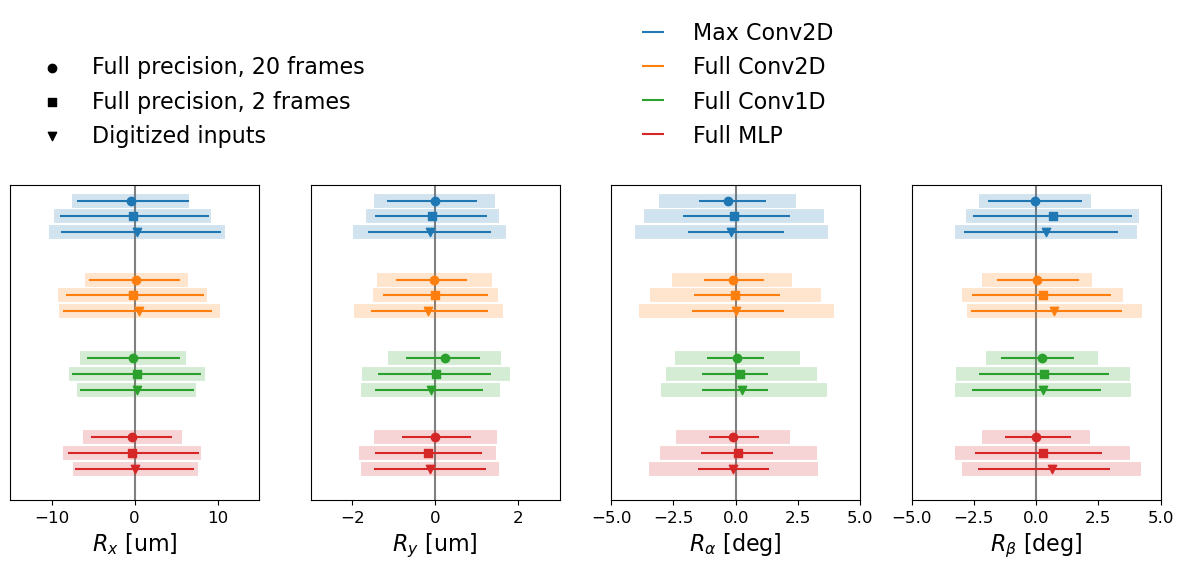

In [8]:
fig, ax = plt.subplots(2,4,figsize=(12,6),sharey=True, constrained_layout=True, gridspec_kw={'height_ratios': [1, 2]})

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[0,3].axis('off')

names2 = {}
names2['1-noquant_20t'] = 'Full precision, 20 frames'
names2['2-noquant_2t'] = 'Full precision, 2 frames'
names2['3-input_dig_2t'] = 'Digitized inputs'
#names2['4-quantized'] = 'Quantized NN'

names = {}
names['max_2dconv'] = 'Max Conv2D'
names['full_2dconv'] = 'Full Conv2D'
names['full_1dconv'] = 'Full Conv1D'
names['full_mlp'] = 'Full MLP'

labels = list(names.keys())
labels2 = list(names2.keys())

format_plot(ax, len(labels))

lines = []

for i,k1 in enumerate(labels):
        
    print("Model = " + k1 + "--------------")

    d = residuals[k1]
    
    line, dots = draw_one_model(i, d, labels2, ax)
    lines += [line[0]]
    
gs = ax[0, 2].get_gridspec()
ax[0,0].remove()
ax[0,1].remove()
axbig = fig.add_subplot(gs[0, 0:2])
axbig.axis('off')
ax[0,2].legend(lines,[names[l] for l in labels],frameon=False,loc='lower left',fontsize=fontsize)
axbig.legend(dots,[names2[l] for l in labels2],fontsize=fontsize,frameon=False,loc='lower left')

plt.tight_layout()

plt.savefig("dataset2s/plots/res-max.pdf")
plt.savefig("dataset2s/plots/res-max.png")

plt.show()

Model = slim_2dconv--------------
Model = slim_1dconv--------------
Model = slim_mlp--------------


/tmp/ipykernel_1663507/559701965.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


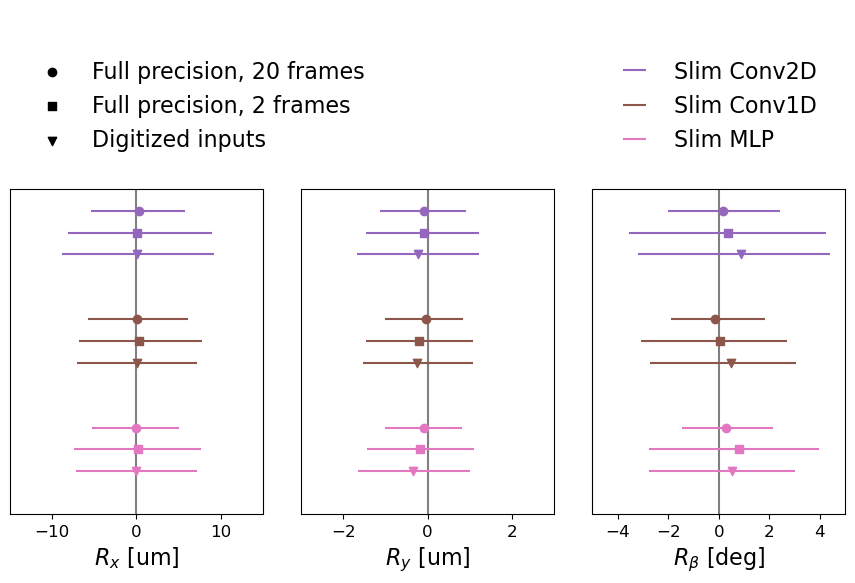

In [9]:
fig, ax = plt.subplots(2,3,figsize=(9,6),sharey=True,constrained_layout=True, gridspec_kw={'height_ratios': [1, 2]})

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')

names2 = {}
names2['1-noquant_20t'] = 'Full precision, 20 frames'
names2['2-noquant_2t'] = 'Full precision, 2 frames'
names2['3-input_dig_2t'] = 'Digitized inputs'
#names2['4-quantized'] = 'Quantized NN'

names = {}
names['slim_2dconv'] = 'Slim Conv2D'
names['slim_1dconv'] = 'Slim Conv1D'
names['slim_mlp'] = 'Slim MLP'

labels = list(names.keys())
labels2 = list(names2.keys())

format_plot(ax, len(labels), slim=True)

lines = []

for i,k1 in enumerate(labels):


    if len(residuals[k1]) == 0:
        continue
        
    print("Model = " + k1 + "--------------")

    d = {k2: residuals[k1][k2] for k2 in labels2}
    
    line, dots = draw_one_model(i, d, labels2, ax, slim=True)
    lines += [line[0]]

gs = ax[0, 2].get_gridspec()
ax[0,0].remove()
ax[0,1].remove()
axbig = fig.add_subplot(gs[0, 0:2])
axbig.axis('off')
ax[0,2].legend(lines,[names[l] for l in labels],frameon=False,loc='lower left',fontsize=fontsize)
axbig.legend(dots,[names2[l] for l in labels2],fontsize=fontsize,frameon=False,loc='lower left')

plt.tight_layout()

plt.savefig("dataset2s/plots/res-slim.pdf")
plt.savefig("dataset2s/plots/res-slim.png")

plt.show()